
# Synthetic Oracle-Z Results: \(d_z=1\) vs \(d_z=20\)

This notebook analyzes the latest `synthetic_oracle_z` experiment.

The experiment compares:

- `true_dgp`: known event-survival function from the simulator;
- `no_latent`: \(x\)-only joint Weibull model;
- `inferred_dvfm_d1`: inferred DVFM with \(d_z=1\);
- `inferred_dvfm_d20`: inferred DVFM with \(d_z=20\);
- `oracle_z`: the same shared decoder trained with the true simulated scalar \(z_i\).

Both inferred DVFM models are trained for the **full 200 epochs** and the **final epoch-200 model is evaluated**. The best validation reconstruction-NLL epoch is retained only as a diagnostic; it is not restored.

The inferred models are each evaluated under two baseline marginalization rules:

- `prior_N01`: \(z\sim N(0,I_d)\);
- `qagg`: sample from the aggregate training posterior.

Oracle-Z is evaluated under:

- `prior_N01`: \(z\sim N(0,1)\);
- `empirical_train_true_z`: sample from the empirical training distribution of the true \(z_i\).

The central comparisons are:

1. \(d_z=1\) versus \(d_z=20\);
2. prior versus \(q_{\mathrm{agg}}\) for the same fitted model;
3. latent recovery and learned dependence after the full 200-epoch training schedule.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = Path("../results/synthetic_oracle_z")
RAW_PATH = RESULT_DIR / "results_raw.csv"
PROFILE_PATH = RESULT_DIR / "latent_effect_profiles.csv"
HISTORY_DIR = RESULT_DIR / "training_history"

print("Result directory:", RESULT_DIR.resolve())

if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Missing {RAW_PATH}. Run synthetic_oracle_z or change RESULT_DIR."
    )


Result directory: /home/thecml/dvfm-survival/results/synthetic_oracle_z


## 1. Load and validate results

In [2]:

results = pd.read_csv(RAW_PATH)
profiles = pd.read_csv(PROFILE_PATH) if PROFILE_PATH.exists() else pd.DataFrame()

if "prediction_distribution" not in results.columns:
    # Backward-compatible fallback for older runs.
    results["prediction_distribution"] = np.where(
        results["architecture"].eq("true_dgp"), "true_dgp",
        np.where(results["architecture"].eq("no_latent"), "none", "prior_N01")
    )

results["model_prediction"] = (
    results["architecture"].astype(str)
    + " | "
    + results["prediction_distribution"].astype(str)
)

print(f"Rows: {len(results)}")
print("\nRows by architecture and prediction distribution:")
display(
    results.groupby(
        ["architecture", "prediction_distribution"],
        dropna=False
    ).size().rename("n").reset_index()
)

display(results)


Rows: 18

Rows by architecture and prediction distribution:


,architecture,prediction_distribution,n
0,inferred_dvfm,prior_N01,3
1,inferred_dvfm,qagg,3
2,no_latent,none,3
3,oracle_z,empirical_train_true_z,3
4,oracle_z,prior_N01,3
5,true_dgp,true_dgp,3


,seed,architecture,prediction_distribution,target_tau,target_censoring,achieved_censoring,overall_time_tau,learned_conditional_tau,n_parameters,best_epoch,...,latent_uncensored_tanhz_spearman,latent_uncensored_tanhz_kendall,latent_censored_n,latent_censored_z_pearson,latent_censored_z_spearman,latent_censored_z_kendall,latent_censored_tanhz_pearson,latent_censored_tanhz_spearman,latent_censored_tanhz_kendall,model_prediction
0,0,true_dgp,true_dgp,0.5,0.3,0.2957,0.454579,0.500000,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,true_dgp | true_dgp
1,0,no_latent,none,0.5,0.3,0.2957,0.454579,0.004757,2916,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_latent | none
2,0,inferred_dvfm,prior_N01,0.5,0.3,0.2957,0.454579,-0.241176,6118,10.0,...,-0.002181,-0.001653,591.0,0.048454,0.037346,0.025576,0.027922,0.037346,0.025576,inferred_dvfm | prior_N01
3,0,inferred_dvfm,qagg,0.5,0.3,0.2957,0.454579,-0.241176,6118,10.0,...,-0.002181,-0.001653,591.0,0.048454,0.037346,0.025576,0.027922,0.037346,0.025576,inferred_dvfm | qagg
4,0,oracle_z,prior_N01,0.5,0.3,0.2957,0.454579,0.494109,2948,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,oracle_z | prior_N01
5,0,oracle_z,empirical_train_true_z,0.5,0.3,0.2957,0.454579,0.494109,2948,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,oracle_z | empirical_train_true_z
6,1,true_dgp,true_dgp,0.5,0.3,0.3068,0.455941,0.500000,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,true_dgp | true_dgp
7,1,no_latent,none,0.5,0.3,0.3068,0.455941,-0.002030,2916,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_latent | none
8,1,inferred_dvfm,prior_N01,0.5,0.3,0.3068,0.455941,-0.258521,6118,6.0,...,0.024503,0.016040,614.0,0.076310,0.080466,0.053674,0.075736,0.080466,0.053674,inferred_dvfm | prior_N01
9,1,inferred_dvfm,qagg,0.5,0.3,0.3068,0.455941,-0.258521,6118,6.0,...,0.024503,0.016040,614.0,0.076310,0.080466,0.053674,0.075736,0.080466,0.053674,inferred_dvfm | qagg



Because the inferred DVFM and oracle-Z now each produce two prediction rows from the **same fitted model**, model-level diagnostics such as best epoch, learned \(\tau\), and latent recovery should be deduplicated before summarizing them.


In [3]:

# One row per fitted model/seed for diagnostics that do not depend on prediction distribution.
model_rows = (
    results.sort_values(["seed", "architecture", "prediction_distribution"])
    .drop_duplicates(["seed", "architecture"])
    .copy()
)

print("Unique fitted-model rows:", len(model_rows))
display(
    model_rows[[
        c for c in [
            "seed", "architecture", "latent_dim",
            "best_epoch", "evaluated_epoch", "epochs_completed",
            "checkpoint_selection_metric",
            "best_validation_reconstruction_nll",
            "learned_conditional_tau"
        ] if c in model_rows.columns
    ]].sort_values(["architecture", "seed"])
)


Unique fitted-model rows: 12


,seed,architecture,best_epoch,epochs_completed,checkpoint_selection_metric,best_validation_reconstruction_nll,learned_conditional_tau
2,0,inferred_dvfm,10.0,200.0,none_final_epoch_evaluated,-4.028828,-0.241176
8,1,inferred_dvfm,6.0,200.0,none_final_epoch_evaluated,-4.349131,-0.258521
14,2,inferred_dvfm,9.0,200.0,none_final_epoch_evaluated,-4.211015,-0.255308
1,0,no_latent,13.0,200.0,none_final_epoch_evaluated,-3.472166,0.004757
7,1,no_latent,14.0,200.0,none_final_epoch_evaluated,-3.812189,-0.002030
13,2,no_latent,12.0,200.0,none_final_epoch_evaluated,-3.642285,-0.001832
5,0,oracle_z,24.0,200.0,none_final_epoch_evaluated,-4.207486,0.494109
11,1,oracle_z,34.0,200.0,none_final_epoch_evaluated,-4.482173,0.489208
17,2,oracle_z,45.0,200.0,none_final_epoch_evaluated,-4.390771,0.525415
0,0,true_dgp,NaN,NaN,NaN,NaN,0.500000



## 2. Training-schedule sanity check

All fitted models should complete the full configured schedule, and the latent models should be evaluated at the **final epoch**. `best_epoch` below is only the epoch with the lowest validation reconstruction NLL; it is a diagnostic and is **not** the evaluated checkpoint.


,seed,architecture,best_epoch,epochs_completed,checkpoint_selection_metric,best_validation_reconstruction_nll,best_validation_loss
2,0,inferred_dvfm,10.0,200.0,none_final_epoch_evaluated,-4.028828,-4.028828
8,1,inferred_dvfm,6.0,200.0,none_final_epoch_evaluated,-4.349131,-4.349131
14,2,inferred_dvfm,9.0,200.0,none_final_epoch_evaluated,-4.211015,-4.211015
1,0,no_latent,13.0,200.0,none_final_epoch_evaluated,-3.472166,-3.472166
7,1,no_latent,14.0,200.0,none_final_epoch_evaluated,-3.812189,-3.812189
13,2,no_latent,12.0,200.0,none_final_epoch_evaluated,-3.642285,-3.642285
5,0,oracle_z,24.0,200.0,none_final_epoch_evaluated,-4.207486,-4.207486
11,1,oracle_z,34.0,200.0,none_final_epoch_evaluated,-4.482173,-4.482173
17,2,oracle_z,45.0,200.0,none_final_epoch_evaluated,-4.390771,-4.390771


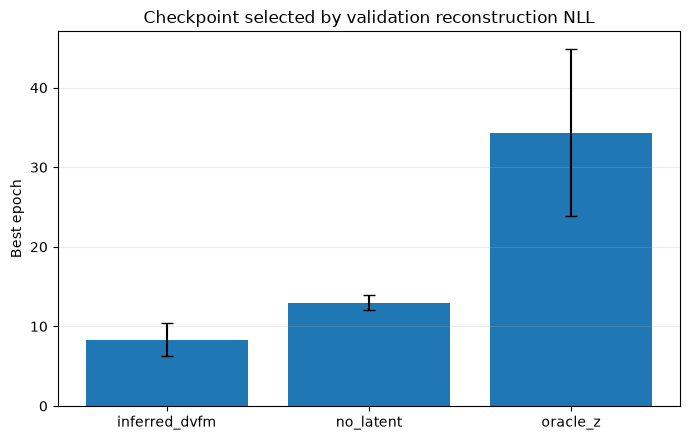

In [4]:

trained = model_rows[model_rows["architecture"] != "true_dgp"].copy()

checkpoint_cols = [
    c for c in [
        "seed",
        "architecture",
        "latent_dim",
        "best_epoch",
        "evaluated_epoch",
        "epochs_completed",
        "checkpoint_selection_metric",
        "best_validation_reconstruction_nll",
        "best_validation_loss",
    ]
    if c in trained.columns
]
display(trained[checkpoint_cols].sort_values(["architecture", "seed"]))

if "best_epoch" in trained.columns:
    p = (
        trained.groupby("architecture", as_index=False)
        .agg(
            mean_best_nll_epoch=("best_epoch", "mean"),
            std_best_nll_epoch=("best_epoch", "std"),
            mean_evaluated_epoch=("evaluated_epoch", "mean")
            if "evaluated_epoch" in trained.columns
            else ("epochs_completed", "mean"),
        )
    )

    fig, ax = plt.subplots(figsize=(8, 4.8))
    x = np.arange(len(p))
    ax.bar(
        x,
        p["mean_best_nll_epoch"],
        yerr=p["std_best_nll_epoch"],
        capsize=4,
        label="Best validation-NLL epoch",
    )
    ax.scatter(
        x,
        p["mean_evaluated_epoch"],
        marker="x",
        s=70,
        label="Evaluated final epoch",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(p["architecture"], rotation=20, ha="right")
    ax.set_ylabel("Epoch")
    ax.set_title("Best-NLL epoch versus evaluated final epoch")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


## 3. Primary result: prior vs aggregate-posterior prediction

In [5]:

prediction_summary = (
    results.groupby(
        ["architecture", "prediction_distribution"],
        as_index=False,
        dropna=False,
    )
    .agg(
        oracle_ibs_mean=("oracle_ibs", "mean"),
        oracle_ibs_std=("oracle_ibs", "std"),
        oracle_ci_mean=("oracle_ci_rmst", "mean"),
        oracle_ci_std=("oracle_ci_rmst", "std"),
        n_seeds=("seed", "nunique"),
    )
)
prediction_summary["label"] = (
    prediction_summary["architecture"]
    + " | "
    + prediction_summary["prediction_distribution"]
)

display(prediction_summary.sort_values("oracle_ibs_mean"))


,architecture,prediction_distribution,oracle_ibs_mean,oracle_ibs_std,oracle_ci_mean,oracle_ci_std,n_seeds,label
5,true_dgp,true_dgp,0.120262,0.004484,0.578178,0.004669,3,true_dgp | true_dgp
3,oracle_z,empirical_train_true_z,0.121628,0.003380,0.565600,0.008917,3,oracle_z | empirical_train_true_z
4,oracle_z,prior_N01,0.121955,0.003024,0.568592,0.009139,3,oracle_z | prior_N01
2,no_latent,none,0.137428,0.003393,0.553846,0.010542,3,no_latent | none
0,inferred_dvfm,prior_N01,0.155156,0.010624,0.566255,0.009000,3,inferred_dvfm | prior_N01
1,inferred_dvfm,qagg,0.160697,0.003478,0.564623,0.008651,3,inferred_dvfm | qagg


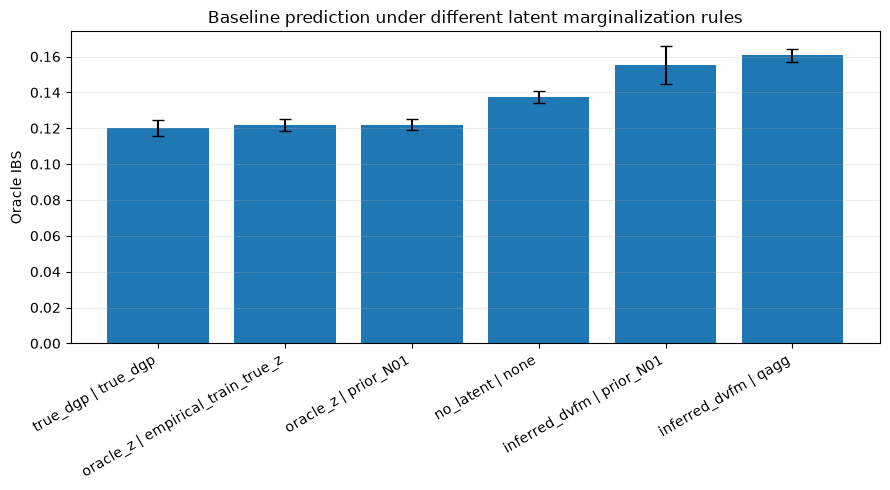

In [6]:

p = prediction_summary.sort_values("oracle_ibs_mean").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(p))
ax.bar(
    x,
    p["oracle_ibs_mean"],
    yerr=p["oracle_ibs_std"],
    capsize=4,
)
ax.set_xticks(x)
ax.set_xticklabels(p["label"], rotation=30, ha="right")
ax.set_ylabel("Oracle IBS")
ax.set_title("Baseline prediction under different latent marginalization rules")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()



The most important comparisons are now:

\[
d_z=1 \quad\text{vs}\quad d_z=20
\]

under the same prediction rule, and within each dimension:

\[
\text{prior }N(0,I_d)
\quad\text{vs}\quad
q_{\mathrm{agg}}.
\]


Inferred DVFM: qagg - prior Oracle IBS


prediction_distribution,seed,prior_N01,qagg,delta_qagg_minus_prior
0,0,0.167414,0.162228,-0.005186
1,1,0.149446,0.163146,0.013700
2,2,0.148607,0.156717,0.008109


Mean delta: 0.005541060315460135 (negative means qagg is better)


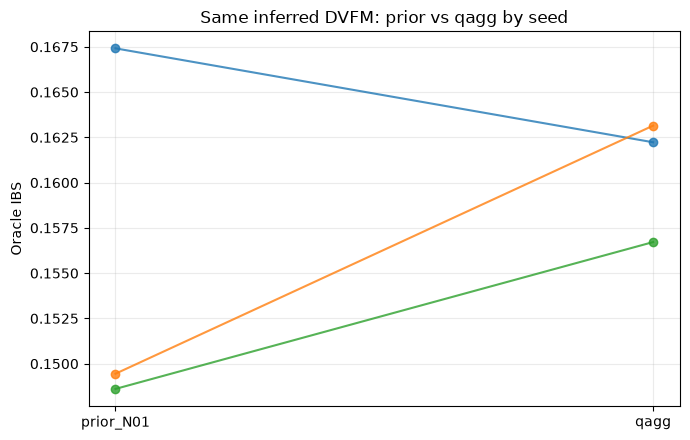

In [7]:

inferred_pred = results[
    results["architecture"].astype(str).str.startswith("inferred_dvfm")
].copy()

for architecture in sorted(inferred_pred["architecture"].unique()):
    part = inferred_pred[inferred_pred["architecture"] == architecture].copy()

    if {"prior_N01", "qagg"}.issubset(set(part["prediction_distribution"])):
        paired = (
            part.pivot(
                index="seed",
                columns="prediction_distribution",
                values="oracle_ibs",
            )
            .reset_index()
        )
        paired["delta_qagg_minus_prior"] = paired["qagg"] - paired["prior_N01"]

        print(f"\n{architecture}: qagg - prior Oracle IBS")
        display(paired)

        print(
            "Mean delta:",
            paired["delta_qagg_minus_prior"].mean(),
            "(negative means qagg is better)"
        )

        fig, ax = plt.subplots(figsize=(6.5, 4.2))
        for _, row in paired.iterrows():
            ax.plot(
                ["prior_N01", "qagg"],
                [row["prior_N01"], row["qagg"]],
                marker="o",
                alpha=0.8,
            )
        ax.set_ylabel("Oracle IBS")
        ax.set_title(f"{architecture}: prior vs qagg by seed")
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


## 4. Oracle-Z distribution check

In [8]:

oracle_pred = results[results["architecture"] == "oracle_z"].copy()

if {"prior_N01", "empirical_train_true_z"}.issubset(
    set(oracle_pred["prediction_distribution"])
):
    paired_oracle = (
        oracle_pred.pivot(
            index="seed",
            columns="prediction_distribution",
            values="oracle_ibs",
        )
        .reset_index()
    )
    paired_oracle["delta_empirical_minus_prior"] = (
        paired_oracle["empirical_train_true_z"]
        - paired_oracle["prior_N01"]
    )

    display(paired_oracle)
    print(
        "Mean empirical true-z minus prior delta:",
        paired_oracle["delta_empirical_minus_prior"].mean()
    )
else:
    print("Both Oracle-Z marginalization distributions are not present.")


prediction_distribution,seed,empirical_train_true_z,prior_N01,delta_empirical_minus_prior
0,0,0.125458,0.125126,0.000331
1,1,0.120367,0.121635,-0.001267
2,2,0.119059,0.119105,-0.000046


Mean empirical true-z minus prior delta: -0.00032718365553013423



Because the true DGP has \(Z\sim N(0,1)\), `oracle_z | prior_N01` and
`oracle_z | empirical_train_true_z` should be close for a sufficiently large training sample.
A large gap would indicate Monte Carlo or finite-sample effects worth investigating.


## 5. Learned event/censor dependence

,architecture,tau_mean,tau_std
0,inferred_dvfm,-0.251668,0.009228
1,no_latent,0.000298,0.003863
2,oracle_z,0.502911,0.019643
3,true_dgp,0.500000,0.000000


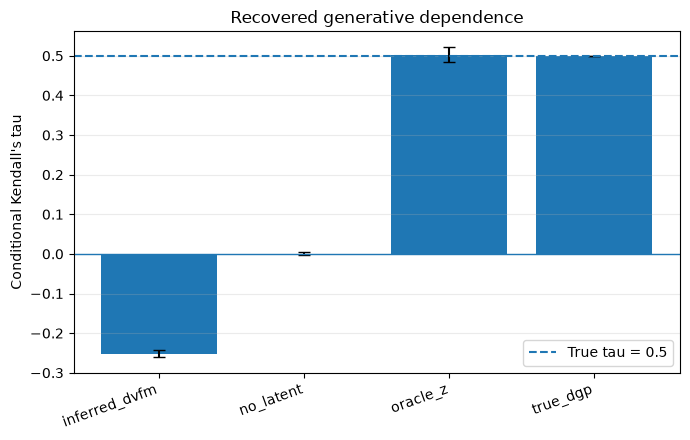

In [9]:

if "learned_conditional_tau" in model_rows.columns:
    tau_df = (
        model_rows.groupby("architecture", as_index=False)
        .agg(
            tau_mean=("learned_conditional_tau", "mean"),
            tau_std=("learned_conditional_tau", "std"),
        )
    )

    display(tau_df)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = np.arange(len(tau_df))
    ax.bar(x, tau_df["tau_mean"], yerr=tau_df["tau_std"], capsize=4)
    target_tau = float(results["target_tau"].dropna().iloc[0]) if "target_tau" in results else 0.5
    ax.axhline(target_tau, linestyle="--", label=f"True tau = {target_tau:g}")
    ax.axhline(0.0, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(tau_df["architecture"], rotation=20, ha="right")
    ax.set_ylabel("Conditional Kendall's tau")
    ax.set_title("Recovered generative dependence")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()



`learned_conditional_tau` is a property of the fitted decoder, so it is intentionally shown once per fitted model rather than once per prediction distribution.


## 6. Latent recovery: all / uncensored / censored

In [10]:

inferred_models = model_rows[
    model_rows["architecture"].astype(str).str.startswith("inferred_dvfm")
].copy()

latent_cols = [
    c for c in inferred_models.columns
    if c.startswith("latent_")
    and any(metric in c for metric in ["pearson", "spearman", "kendall"])
]

print(f"Found {len(latent_cols)} latent-recovery columns.")
print("Inferred architectures:", sorted(inferred_models["architecture"].unique()))
for c in latent_cols:
    print(c)


Found 18 latent-recovery columns.
latent_all_z_pearson
latent_all_z_spearman
latent_all_z_kendall
latent_all_tanhz_pearson
latent_all_tanhz_spearman
latent_all_tanhz_kendall
latent_uncensored_z_pearson
latent_uncensored_z_spearman
latent_uncensored_z_kendall
latent_uncensored_tanhz_pearson
latent_uncensored_tanhz_spearman
latent_uncensored_tanhz_kendall
latent_censored_z_pearson
latent_censored_z_spearman
latent_censored_z_kendall
latent_censored_tanhz_pearson
latent_censored_tanhz_spearman
latent_censored_tanhz_kendall


In [11]:

def latent_metric_table(target="z", metric="spearman"):
    rows = []
    for architecture in sorted(inferred_models["architecture"].unique()):
        part = inferred_models[inferred_models["architecture"] == architecture]
        for subgroup in ["all", "uncensored", "censored"]:
            col = f"latent_{subgroup}_{target}_{metric}"
            if col in part.columns:
                rows.append({
                    "architecture": architecture,
                    "subgroup": subgroup,
                    "mean": part[col].mean(),
                    "std": part[col].std(),
                    "n_seeds": part[col].notna().sum(),
                })
    return pd.DataFrame(rows)

for target in ["z", "tanhz"]:
    for metric in ["pearson", "spearman", "kendall"]:
        tbl = latent_metric_table(target=target, metric=metric)
        if len(tbl):
            print(f"\nTarget={target}, metric={metric}")
            display(tbl)



Target=z, metric=pearson


,subgroup,mean,std,n_seeds
0,all,0.097971,0.028293,3
1,uncensored,0.009115,0.015066,3
2,censored,0.063960,0.014193,3



Target=z, metric=spearman


,subgroup,mean,std,n_seeds
0,all,0.084348,0.024872,3
1,uncensored,0.011696,0.013374,3
2,censored,0.062472,0.022427,3



Target=z, metric=kendall


...

,subgroup,mean,std,n_seeds
0,all,0.094036,0.028971,3
1,uncensored,0.012687,0.013088,3
2,censored,0.055450,0.024716,3



Target=tanhz, metric=spearman


,subgroup,mean,std,n_seeds
0,all,0.084348,0.024872,3
1,uncensored,0.011696,0.013374,3
2,censored,0.062472,0.022427,3



Target=tanhz, metric=kendall


,subgroup,mean,std,n_seeds
0,all,0.056295,0.016466,3
1,uncensored,0.007811,0.008911,3
2,censored,0.041477,0.014411,3


,target,subgroup,mean,std
0,z,all,0.084348,0.024872
1,z,uncensored,0.011696,0.013374
2,z,censored,0.062472,0.022427
3,tanhz,all,0.084348,0.024872
4,tanhz,uncensored,0.011696,0.013374
5,tanhz,censored,0.062472,0.022427


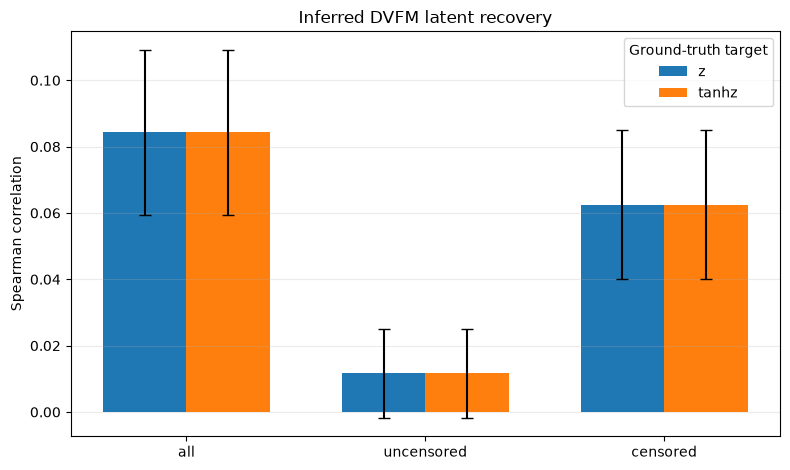

In [12]:

rows = []
for target in ["z", "tanhz"]:
    for subgroup in ["all", "uncensored", "censored"]:
        col = f"latent_{subgroup}_{target}_spearman"
        if col in inferred_models.columns:
            rows.append({
                "target": target,
                "subgroup": subgroup,
                "mean": inferred_models[col].mean(),
                "std": inferred_models[col].std(),
            })

latent_spearman = pd.DataFrame(rows)
display(latent_spearman)

if len(latent_spearman):
    subgroups = ["all", "uncensored", "censored"]
    targets = [
        t for t in ["z", "tanhz"]
        if t in latent_spearman["target"].unique()
    ]
    x = np.arange(len(subgroups))
    width = 0.35 if len(targets) > 1 else 0.6

    fig, ax = plt.subplots(figsize=(8, 4.8))
    for j, target in enumerate(targets):
        p = latent_spearman[
            latent_spearman["target"] == target
        ].set_index("subgroup")
        means = [p.loc[s, "mean"] if s in p.index else np.nan for s in subgroups]
        stds = [p.loc[s, "std"] if s in p.index else np.nan for s in subgroups]
        offset = (j - (len(targets)-1)/2) * width
        ax.bar(
            x + offset,
            means,
            width=width,
            yerr=stds,
            capsize=4,
            label=target,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(subgroups)
    ax.set_ylabel("Spearman correlation")
    ax.set_title("Inferred DVFM latent recovery")
    ax.legend(title="Ground-truth target")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()



rows = []
for architecture in sorted(inferred_models["architecture"].unique()):
    part = inferred_models[inferred_models["architecture"] == architecture]
    for subgroup in ["all", "uncensored", "censored"]:
        col = f"latent_{subgroup}_z_spearman"
        if col in part.columns:
            rows.append({
                "architecture": architecture,
                "subgroup": subgroup,
                "mean": part[col].mean(),
                "std": part[col].std(),
            })

latent_spearman = pd.DataFrame(rows)
display(latent_spearman)

if len(latent_spearman):
    subgroups = ["all", "uncensored", "censored"]
    architectures = sorted(latent_spearman["architecture"].unique())
    x = np.arange(len(subgroups))
    width = 0.35 if len(architectures) > 1 else 0.6

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    for j, architecture in enumerate(architectures):
        p = latent_spearman[
            latent_spearman["architecture"] == architecture
        ].set_index("subgroup")

        means = [p.loc[s, "mean"] if s in p.index else np.nan for s in subgroups]
        stds = [p.loc[s, "std"] if s in p.index else np.nan for s in subgroups]
        offset = (j - (len(architectures)-1)/2) * width

        ax.bar(
            x + offset,
            means,
            width=width,
            yerr=stds,
            capsize=4,
            label=architecture,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(subgroups)
    ax.set_ylabel("Spearman correlation")
    ax.set_title("Latent recovery: d=1 vs d=20")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


,seed,latent_all_z_spearman,latent_uncensored_z_spearman,latent_censored_z_spearman
2,0,0.096631,-0.002181,0.037346
8,1,0.100688,0.024503,0.080466
14,2,0.055723,0.012768,0.069604


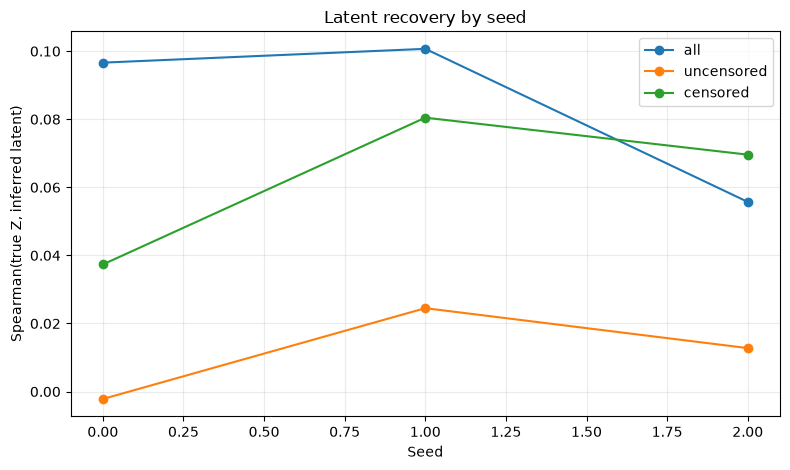

In [13]:

preferred = [
    "latent_all_z_spearman",
    "latent_uncensored_z_spearman",
    "latent_censored_z_spearman",
]

available = [c for c in preferred if c in inferred_models.columns]
if available:
    display(inferred_models[["seed"] + available].sort_values("seed"))

    fig, ax = plt.subplots(figsize=(8, 4.8))
    p = inferred_models.sort_values("seed")
    for col in available:
        label = col.replace("latent_", "").replace("_z_spearman", "")
        ax.plot(p["seed"], p[col], marker="o", label=label)
    ax.set_xlabel("Seed")
    ax.set_ylabel("Spearman(true Z, inferred latent)")
    ax.set_title("Latent recovery by seed")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()



preferred = [
    "latent_all_z_spearman",
    "latent_uncensored_z_spearman",
    "latent_censored_z_spearman",
]

available = [c for c in preferred if c in inferred_models.columns]
if available:
    display(
        inferred_models[
            ["seed", "architecture", "latent_dim"] + available
        ].sort_values(["architecture", "seed"])
    )

    for col in available:
        fig, ax = plt.subplots(figsize=(7.5, 4.2))
        for architecture in sorted(inferred_models["architecture"].unique()):
            p = inferred_models[
                inferred_models["architecture"] == architecture
            ].sort_values("seed")
            ax.plot(
                p["seed"],
                p[col],
                marker="o",
                label=architecture,
            )
        ax.set_xlabel("Seed")
        ax.set_ylabel(col)
        ax.set_title(col.replace("_", " "))
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


,seed,architecture,z,event_shape,event_scale,event_mean,censor_shape,censor_scale,censor_mean
0,0,inferred_dvfm,-3.0,0.319443,27.047436,191.635181,0.678335,0.005983,0.007811
1,0,inferred_dvfm,-2.0,0.388195,8.315501,30.081392,0.733758,0.005614,0.006809
2,0,inferred_dvfm,-1.0,0.578921,0.052101,0.082266,0.643043,0.007958,0.011005
3,0,inferred_dvfm,0.0,0.680590,0.006620,0.008614,0.634402,0.782816,1.099523
4,0,inferred_dvfm,1.0,0.659841,0.005649,0.007593,1.040740,4.394550,4.324572


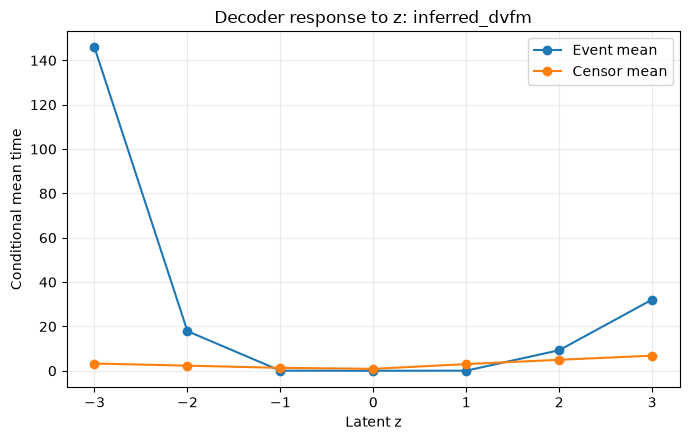

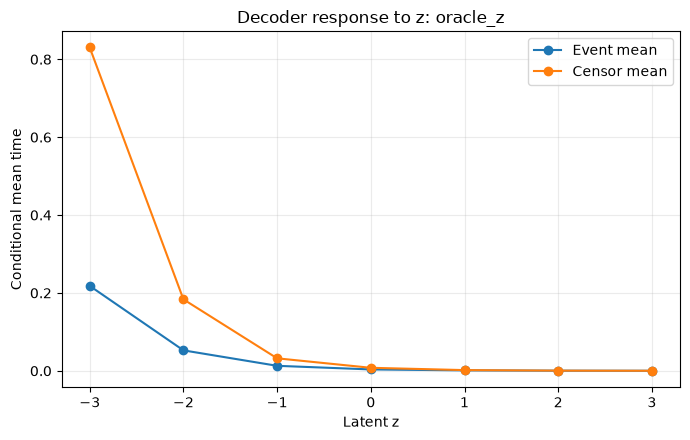

In [14]:

if profiles.empty:
    print("No latent_effect_profiles.csv found.")
else:
    display(profiles.head())

    # Scalar profiles are meaningful for Oracle-Z and inferred d=1.
    # The d=20 inferred model is intentionally omitted by the experiment.
    for architecture in sorted(profiles["architecture"].dropna().unique()):
        p = profiles[profiles["architecture"] == architecture]
        if p.empty:
            continue

        avg = (
            p.groupby("z", as_index=False)
            .agg(
                event_mean=("event_mean", "mean"),
                censor_mean=("censor_mean", "mean"),
            )
            .sort_values("z")
        )

        fig, ax = plt.subplots(figsize=(7, 4.5))
        ax.plot(avg["z"], avg["event_mean"], marker="o", label="Event mean")
        ax.plot(avg["z"], avg["censor_mean"], marker="o", label="Censor mean")
        ax.set_xlabel("Latent z")
        ax.set_ylabel("Conditional mean time")
        ax.set_title(f"Decoder response to z: {architecture}")
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


## 9. Training histories

Training histories found: 9


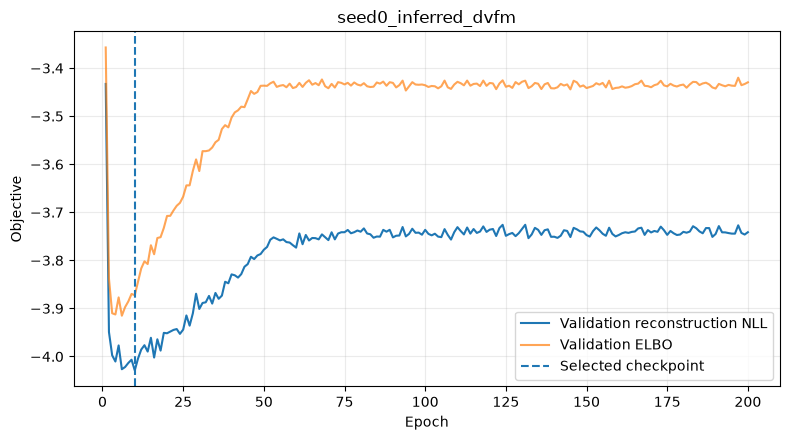

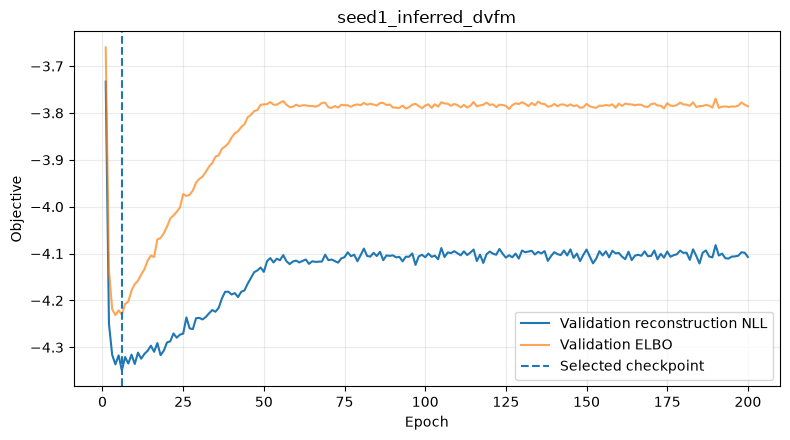

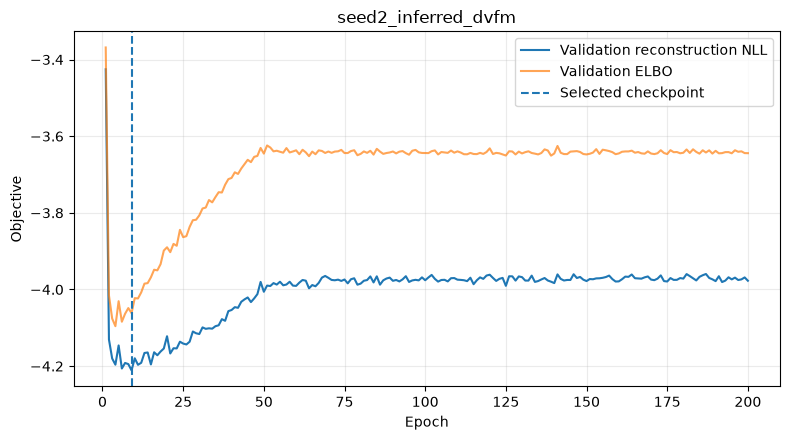

In [15]:

history_files = sorted(HISTORY_DIR.glob("*.csv")) if HISTORY_DIR.exists() else []
print(f"Training histories found: {len(history_files)}")

for path in history_files:
    if "inferred_dvfm" not in path.name:
        continue

    hist = pd.read_csv(path)
    fig, ax = plt.subplots(figsize=(8, 4.5))

    if "validation_reconstruction_nll" in hist.columns:
        ax.plot(
            hist["epoch"],
            hist["validation_reconstruction_nll"],
            label="Validation reconstruction NLL",
        )
    if "validation_loss" in hist.columns:
        ax.plot(
            hist["epoch"],
            hist["validation_loss"],
            label="Validation ELBO",
            alpha=0.7,
        )

    # Mark the minimum validation-NLL epoch and the actually evaluated final epoch.
    if "validation_reconstruction_nll" in hist.columns and len(hist):
        best_idx = hist["validation_reconstruction_nll"].idxmin()
        best_ep = float(hist.loc[best_idx, "epoch"])
        ax.axvline(best_ep, linestyle="--", label="Best val-NLL epoch")

    if len(hist):
        final_ep = float(hist["epoch"].iloc[-1])
        ax.axvline(final_ep, linestyle=":", label="Evaluated final epoch")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Objective")
    ax.set_title(path.stem)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## 10. Compact decision table

In [16]:

decision = prediction_summary.copy()

for architecture in sorted(inferred_models["architecture"].unique()):
    part = inferred_models[inferred_models["architecture"] == architecture]
    for subgroup in ["all", "uncensored", "censored"]:
        col = f"latent_{subgroup}_z_spearman"
        if col in part.columns:
            decision.loc[
                decision["architecture"] == architecture,
                f"{subgroup}_z_spearman_mean"
            ] = part[col].mean()

display(decision.sort_values("oracle_ibs_mean"))


,architecture,prediction_distribution,oracle_ibs_mean,oracle_ibs_std,oracle_ci_mean,oracle_ci_std,n_seeds,label,all_z_spearman_mean,uncensored_z_spearman_mean,censored_z_spearman_mean
5,true_dgp,true_dgp,0.120262,0.004484,0.578178,0.004669,3,true_dgp | true_dgp,NaN,NaN,NaN
3,oracle_z,empirical_train_true_z,0.121628,0.003380,0.565600,0.008917,3,oracle_z | empirical_train_true_z,NaN,NaN,NaN
4,oracle_z,prior_N01,0.121955,0.003024,0.568592,0.009139,3,oracle_z | prior_N01,NaN,NaN,NaN
2,no_latent,none,0.137428,0.003393,0.553846,0.010542,3,no_latent | none,NaN,NaN,NaN
0,inferred_dvfm,prior_N01,0.155156,0.010624,0.566255,0.009000,3,inferred_dvfm | prior_N01,0.084348,0.011696,0.062472
1,inferred_dvfm,qagg,0.160697,0.003478,0.564623,0.008651,3,inferred_dvfm | qagg,0.084348,0.011696,0.062472



## 11. Interpretation guide

### If \(d_z=20\) clearly beats \(d_z=1\)

Then the colleague-style high-dimensional latent is providing useful extra mixture capacity. If true scalar-\(Z\) recovery remains weak, that would suggest the gain is **not** coming from faithful recovery of the actual one-dimensional frailty.

### If \(d_z=20\) also fails

Then latent dimension is not the main explanation for the discrepancy with the colleague's synthetic benchmark. The next clean step is to reproduce the colleague's exact `frailty_mixture` DGP and training setup inside this controlled harness.

### If `qagg` clearly beats `prior_N01`

Then prediction-time latent marginalization explains part of the discrepancy with the reference DVFM implementation.

### If `qagg` and `prior_N01` are similar

Then prediction-time marginalization is not the main explanation.

### If Oracle-Z prior and empirical true-Z are similar

That is the expected sanity result for a true \(Z\sim N(0,1)\) DGP with a large training sample.

### Remember

All inferred models in this notebook are evaluated at the **final training epoch (200)**. The best validation reconstruction-NLL epoch is shown only as a diagnostic and is not restored.
